In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("graph_result.txt")
target_density = 0.1
df_01 = df[df['Density'] == target_density]

print(f"Analyzing performance for fixed Edge Density: {target_density}")

Analyzing performance for fixed Edge Density: 0.1


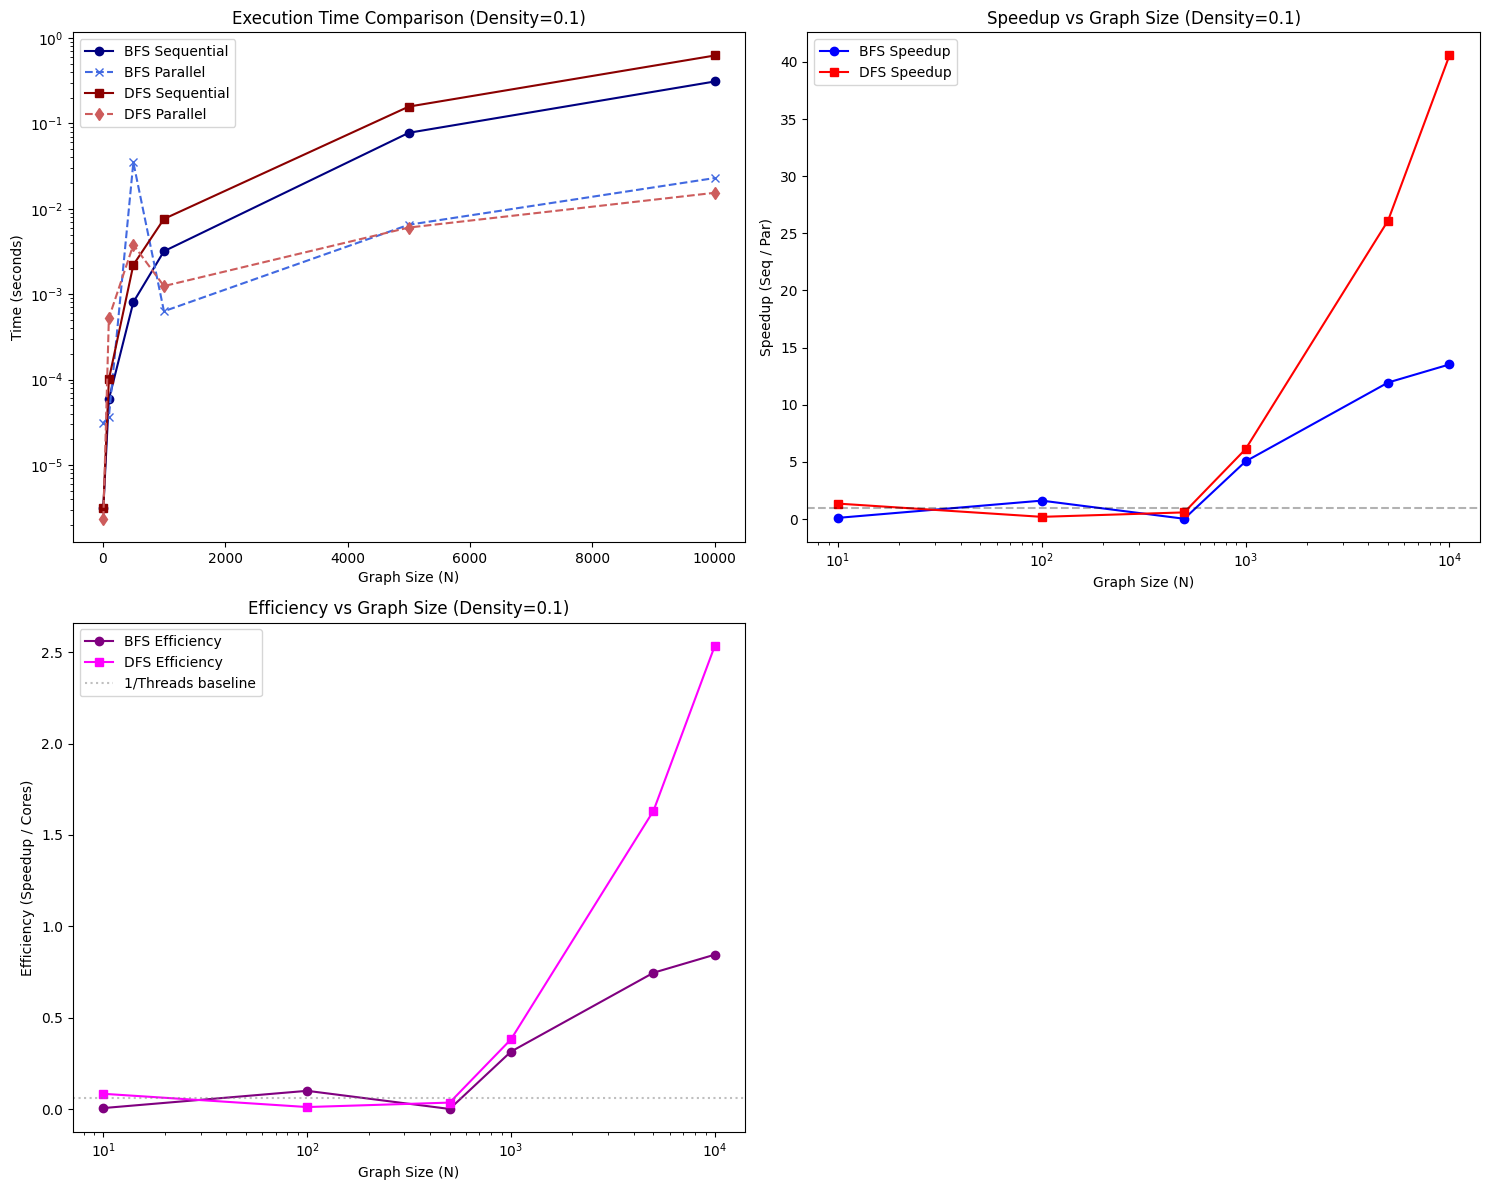

In [30]:
# 1. Parallel vs Sequential (BFS and DFS) for Density 0.1
plt.figure(figsize=(15, 12))

plt.subplot(2, 2, 1)
plt.plot(df_01['N'], df_01['BFS_Seq'], 'o-', label="BFS Sequential", color='navy')
plt.plot(df_01['N'], df_01['BFS_Par'], 'x--', label="BFS Parallel", color='royalblue')
plt.plot(df_01['N'], df_01['DFS_Seq'], 's-', label="DFS Sequential", color='darkred')
plt.plot(df_01['N'], df_01['DFS_Par'], 'd--', label="DFS Parallel", color='indianred')
# plt.xscale('log')
plt.yscale('log')
plt.xlabel("Graph Size (N)")
plt.ylabel("Time (seconds)")
plt.title(f"Execution Time Comparison (Density={target_density})")
plt.legend()

# 2. Speedup (BFS and DFS)
plt.subplot(2, 2, 2)
plt.plot(df_01['N'], df_01['BFS_Speedup'], 'o-', label="BFS Speedup", color='blue')
plt.plot(df_01['N'], df_01['DFS_Speedup'], 's-', label="DFS Speedup", color='red')
plt.axhline(y=1, color='black', linestyle='--', alpha=0.3)
plt.xscale('log')
plt.xlabel("Graph Size (N)")
plt.ylabel("Speedup (Seq / Par)")
plt.title(f"Speedup vs Graph Size (Density={target_density})")
plt.legend()

# 3. Efficiency (BFS and DFS)
plt.subplot(2, 2, 3)
plt.plot(df_01['N'], df_01['BFS_Efficiency'], 'o-', label="BFS Efficiency", color='purple')
plt.plot(df_01['N'], df_01['DFS_Efficiency'], 's-', label="DFS Efficiency", color='magenta')
plt.axhline(y=1/16, color='grey', linestyle=':', alpha=0.5, label="1/Threads baseline")
plt.xscale('log')
plt.xlabel("Graph Size (N)")
plt.ylabel("Efficiency (Speedup / Cores)")
plt.title(f"Efficiency vs Graph Size (Density={target_density})")
plt.legend()

plt.tight_layout()
plt.show()

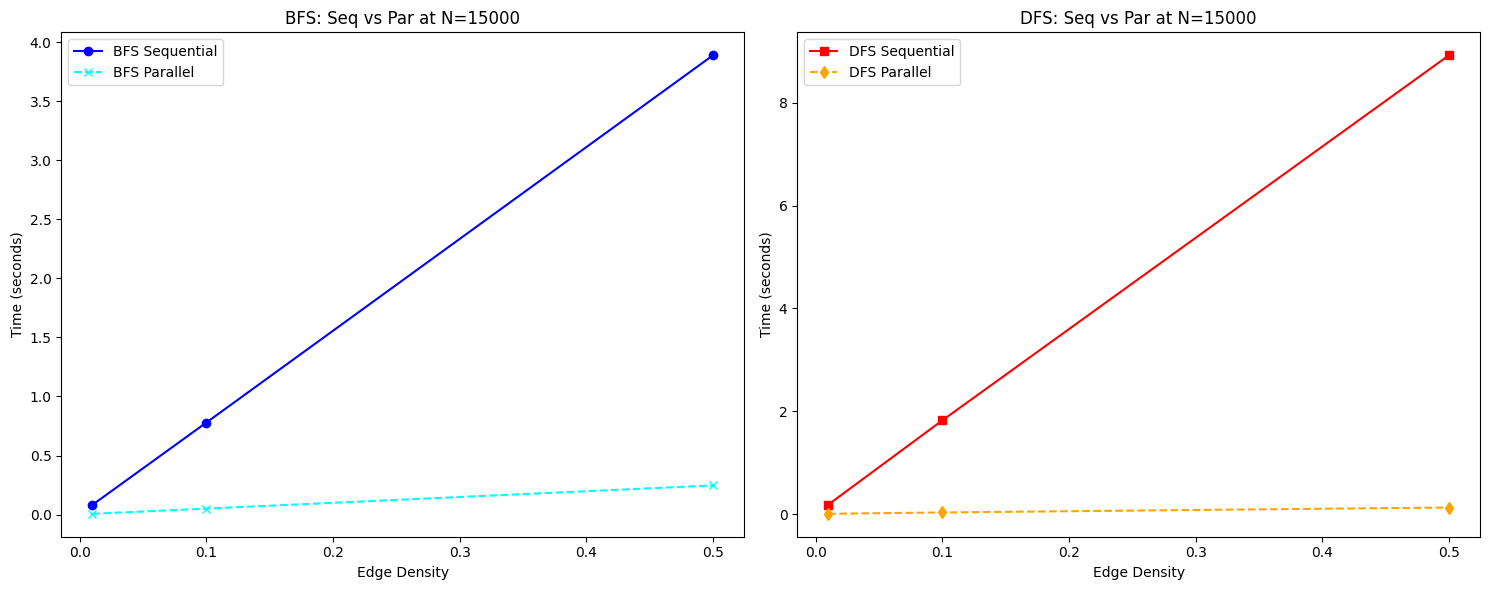

In [23]:
# 4. Impact of Density on Execution Time (Fixed N = 5000)
large_n = df['N'].max()
subset_n = df[df['N'] == large_n]

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(subset_n['Density'], subset_n['BFS_Seq'], 'o-', label="BFS Sequential", color='blue')
plt.plot(subset_n['Density'], subset_n['BFS_Par'], 'x--', label="BFS Parallel", color='cyan')
plt.xlabel("Edge Density")
plt.ylabel("Time (seconds)")
plt.title(f"BFS: Seq vs Par at N={large_n}")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(subset_n['Density'], subset_n['DFS_Seq'], 's-', label="DFS Sequential", color='red')
plt.plot(subset_n['Density'], subset_n['DFS_Par'], 'd--', label="DFS Parallel", color='orange')
plt.xlabel("Edge Density")
plt.ylabel("Time (seconds)")
plt.title(f"DFS: Seq vs Par at N={large_n}")
plt.legend()

plt.tight_layout()
plt.show()